# 03 — Cohort: đổi đối tượng từ khách hàng sang sản phẩm

**Cohort mua lại theo khách hàng — không làm được với dữ liệu này.**
Cohort retention chuẩn cần 1 khoá định danh khách hàng bền vững qua thời
gian (customer ID) để nhóm các đơn theo "tháng mua đầu tiên" của từng khách,
rồi theo dõi bao nhiêu % khách đó còn quay lại ở tháng +1, +2... Toàn bộ 31
cột có thể định danh khách hàng (tên, SĐT, email, địa chỉ...) đã bị loại bỏ
**vĩnh viễn** ngay từ `python/01_clean.py` — đây là quyết định đúng và có
chủ đích để bảo vệ dữ liệu khách hàng thật, không phải sơ suất. Đã kiểm tra 
lại toàn bộ cột còn sót: `lazadaId` có 33.636 giá trị duy nhất trên 33.636 
dòng (là ID cấp dòng, không phải cấp khách), `shippingCity`/`billingCity` 
chỉ tới cấp quận/huyện (669 giá trị, quá thô để định danh 1 khách hàng cụ thể) 
— không có cột nào dùng thay được.

**Hướng đi:** áp dụng đúng kỹ thuật cohort retention, nhưng đổi đối tượng
theo dõi từ **khách hàng** sang **sản phẩm** (`product_code`) — dữ liệu này
có sẵn và đủ tin cậy. Câu hỏi đổi thành: sản phẩm mới ra mắt trong 1 tháng
("cohort") thì bao nhiêu % còn được bán tiếp ở các tháng sau — tức là đo
**vòng đời sản phẩm**, một câu hỏi khác nhưng cùng kỹ thuật, và vẫn trả lời
được nhu cầu kinh doanh thật: sản phẩm nào "sống dai", sản phẩm nào chỉ bán
được 1-2 tháng rồi chết.


In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
con = duckdb.connect("../data/clean/lazada.duckdb", read_only=True)

sales = con.execute("""
    SELECT product_code, order_date
    FROM fact_order_item_customer
""").df()
sales["order_date"] = pd.to_datetime(sales["order_date"])
sales["ym"] = sales["order_date"].dt.to_period("M")

cohort_month = sales.groupby("product_code")["ym"].min().rename("cohort_month")
sales = sales.join(cohort_month, on="product_code")
sales["month_index"] = (sales["ym"] - sales["cohort_month"]).apply(lambda p: p.n)

cohort_sizes = cohort_month.value_counts().sort_index()
print("Số sản phẩm mới theo tháng (cỡ cohort):")
cohort_sizes


Số sản phẩm mới theo tháng (cỡ cohort):


cohort_month
2020-12    16
2021-01    47
2021-02    25
2021-03    38
2021-04    30
2021-05    12
2021-06     5
2021-07     9
2021-08     6
2021-09     4
2021-10     1
2021-11     1
2022-01     2
Freq: M, Name: count, dtype: int64

**Chỗ dễ sai:** cỡ cohort giảm dần rất nhanh sau 03/2021 (25, rồi rải rác vài
sản phẩm/tháng) — không phải vì shop ngừng ra mắt sản phẩm mới, mà vì hầu hết
196 mã đã xuất hiện ngay từ đầu (12/2020–03/2021). Cohort các tháng cuối quá
nhỏ (1-2 sản phẩm) để đọc % retention có ý nghĩa — sẽ loại khỏi biểu đồ.

Dùng gộp cả 2 shop (không lọc riêng Chetanic như notebook 01) vì đây là câu
hỏi về vòng đời **sản phẩm** trên toàn bộ hoạt động, không phải hành vi
khách hàng theo shop.


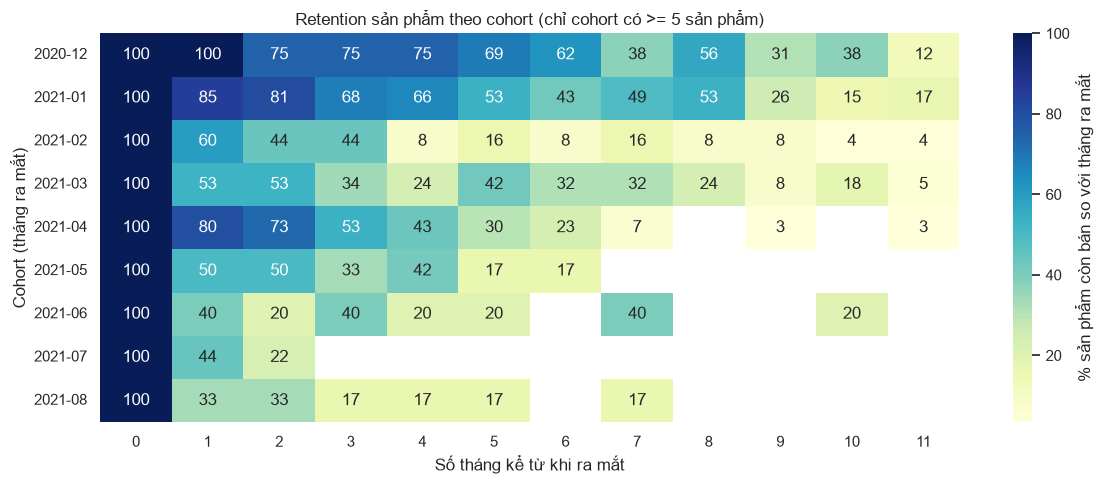

In [2]:
MIN_COHORT_SIZE = 5
big_cohorts = cohort_sizes[cohort_sizes >= MIN_COHORT_SIZE].index

active = (
    sales[sales["cohort_month"].isin(big_cohorts)]
    .groupby(["cohort_month", "month_index"])["product_code"]
    .nunique()
    .reset_index()
)
pivot_n = active.pivot(index="cohort_month", columns="month_index", values="product_code")
pivot_pct = pivot_n.divide(pivot_n[0], axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot_pct.iloc[:, :12], annot=True, fmt=".0f", cmap="YlGnBu",
    cbar_kws={"label": "% sản phẩm còn bán so với tháng ra mắt"}, ax=ax,
)
ax.set_xlabel("Số tháng kể từ khi ra mắt")
ax.set_ylabel("Cohort (tháng ra mắt)")
ax.set_title(f"Retention sản phẩm theo cohort (chỉ cohort có >= {MIN_COHORT_SIZE} sản phẩm)")
plt.tight_layout()
plt.show()


**Đọc kết quả:** 2 cohort đầu tiên (12/2020, 01/2021) "sống dai" rõ rệt — vẫn
còn 12–17% sản phẩm bán được sau 11 tháng. Cohort từ 05/2021 trở đi rơi rất
nhanh, phần lớn biến mất trong 2-3 tháng.

**Chỗ dễ sai — đừng vội kết luận "sản phẩm ra sau kém hơn sản phẩm ra
trước":** có một lời giải thích khác hợp lý không kém — **right-censoring**.
Cohort 12/2020 có tới 23 tháng dữ liệu phía sau để quan sát, còn cohort
08/2021 chỉ còn khoảng 12 tháng (và phần lớn trong đó shop đã giảm hoạt
động mạnh, theo `01_seasonality.ipynb`). Retention thấp ở cohort muộn có thể
đơn thuần vì **thời gian quan sát ngắn hơn cộng với việc toàn shop suy giảm**
sau 03/2022, không hẳn vì bản thân sản phẩm đó kém. Hai nguyên nhân — chất
lượng sản phẩm & thời điểm quan sát bị cắt cụt — không tách bạch được bằng
biểu đồ này một mình.


## Kết luận

Sản phẩm ra mắt sớm (12/2020–01/2021) có vòng đời dài hơn hẳn phần còn lại —
nhiều khả năng đây chính là nhóm sản phẩm chủ lực đã xác định ở các phân
tích trước (SHRTT01 và một số mã lớn khác). Phần lớn sản phẩm mới sau đó có
vòng đời ngắn (2-3 tháng), nhưng không thể tách bạch rõ đây là do sản phẩm
tự nó kém hấp dẫn, hay do bị cắt cụt thời gian quan sát bởi việc shop giảm
hoạt động toàn diện sau 03/2022.

## Giới hạn

**Đây là cohort SẢN PHẨM, không phải cohort KHÁCH HÀNG** — không trả lời
được câu hỏi gốc "khách hàng có quay lại mua không". Cần một khoá định danh
khách hàng bền vững (ẩn danh hoá đúng cách, không phải xoá hẳn như hiện tại)
mới làm được cohort khách hàng thật — đây là điều cần cân nhắc **từ khâu thu
thập/lưu trữ dữ liệu gốc**, không sửa được ở bước phân tích. Right-censoring
(nêu ở trên) chưa được kiểm soát định lượng — muốn làm chuẩn cần kỹ thuật
survival analysis (vd. Kaplan-Meier) thay vì heatmap retention đơn giản.
